<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/17_regression_crossval/17_2_MLR/17_2_4_4_notes_on_curves.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notes on Alpha Tuning Curves and Learning Curves

This notebook reviews and clarifies two important diagnostic visualizations: **Alpha Tuning Curves** and **Learning Curves**. These tools help you understand and debug your models.

**What this is:** A review notebook that clarifies concepts from Part 4. It does not introduce new information.

**Note:** To ensure the principles are shown as clearly as possible, the plots in this notebook use **synthetic pedagogical data** rather than a messy real-world dataset. This allows us to see the "ideal" shapes of these curves.

## Setup: Pedagogical Model Simulators

We will use `numpy` to simulate the behavior of regression models under different conditions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_alpha_tuning(alphas):
    """Simulates the behavior of a Ridge regression model tuning alpha."""
    log_a = np.log10(alphas)
    # Training score: starts high, decays slowly as regularization increases
    train_scores = 0.98 - 0.04 * (log_a + 3)
    
    # Validation score: Peak at alpha = 10 (log_a = 1)
    # Using a parabola in log-space for a smooth "bell" curve
    val_scores = 0.90 - 0.07 * (log_a - 1)**2
    
    # Constraints for pedagogical clarity: 
    # 1. Val score must be below train score
    # 2. Don't let it drop into negative R2 for these plots
    val_scores = np.minimum(val_scores, train_scores - 0.03)
    val_scores = np.maximum(val_scores, 0.2)
    
    return train_scores, val_scores

def simulate_learning_curve(sizes, scenario='normal'):
    """Simulates three classic learning curve patterns."""
    if scenario == 'normal':
        # Convergence is visible but not finished; gap is narrowing
        train = 0.96 - 0.06 * (sizes / max(sizes))
        val = 0.3 + 0.55 * (1 - np.exp(-0.003 * sizes))
    elif scenario == 'overfit':
        # High training, validation struggles to rise (persistent large gap)
        train = 0.98 - 0.02 * (sizes / max(sizes))
        val = 0.4 + 0.15 * (1 - np.exp(-0.008 * sizes))
    elif scenario == 'underfit':
        # Both curves converge quickly to a low "glass ceiling"
        train = 0.5 + 0.4 * np.exp(-0.01 * sizes)
        val = 0.45 - 0.2 * np.exp(-0.01 * sizes)
    
    return train, val

---

## Part 1: Alpha Tuning Curves

### What it shows

An alpha tuning curve plots both the **training score** and the **cross-validation score** against different values of alpha (the regularization strength).

### How to read it

- **Left side (low alpha):** The model is unconstrained. The training score is very high, but the validation score is much lower. This **large gap** indicates **High Variance (Overfitting)**.
- **Right side (high alpha):** Both scores drop significantly. The penalty is so strong that the model is too simple to capture patterns. This is **High Bias (Underfitting)**.
- **The Sweet Spot:** The alpha where the validation score reaches its maximum. This is where the model generalizes best to unseen data.

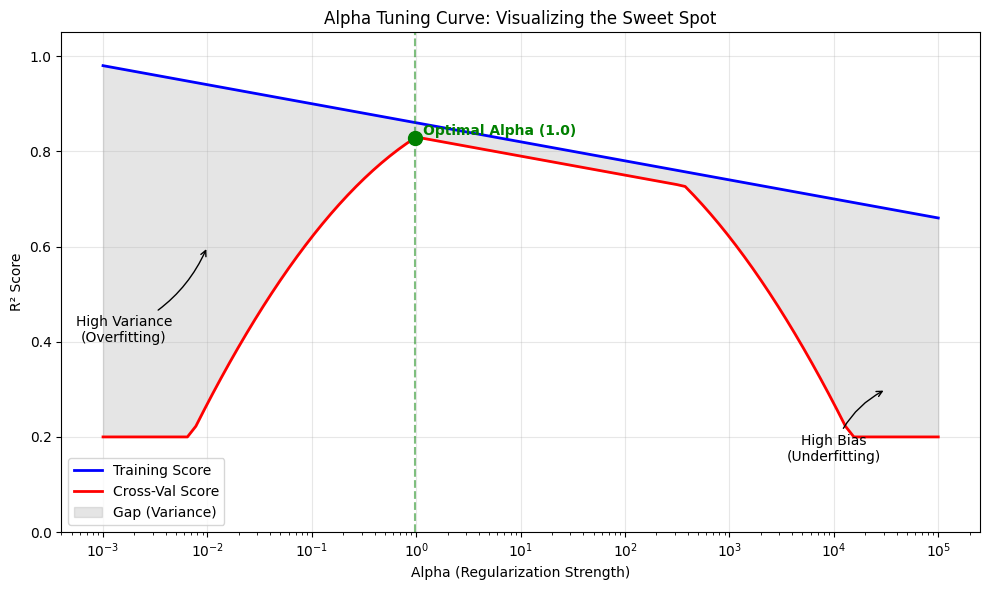

In [2]:
alphas = np.logspace(-3, 5, 100)
train_scores, cv_scores = simulate_alpha_tuning(alphas)

plt.figure(figsize=(10, 6))
plt.semilogx(alphas, train_scores, 'b-', label='Training Score', linewidth=2)
plt.semilogx(alphas, cv_scores, 'r-', label='Cross-Val Score', linewidth=2)

# Highlight the gap
plt.fill_between(alphas, cv_scores, train_scores, color='gray', alpha=0.2, label='Gap (Variance)')

# Mark the Sweet Spot
best_idx = np.argmax(cv_scores)
plt.scatter(alphas[best_idx], cv_scores[best_idx], color='green', s=100, zorder=5)
plt.axvline(alphas[best_idx], color='green', linestyle='--', alpha=0.5)
plt.text(alphas[best_idx]*1.2, cv_scores[best_idx], f'Optimal Alpha ({alphas[best_idx]:.1f})',
         color='green', fontweight='bold', va='bottom')

# Annotations
plt.annotate('High Variance\n(Overfitting)', xy=(10**-2, 0.6), xytext=(10**-2.8, 0.4),
             arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=.2'), ha='center')
plt.annotate('High Bias\n(Underfitting)', xy=(10**4.5, 0.3), xytext=(10**4, 0.15),
             arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=-.2'), ha='center')

plt.xlabel('Alpha (Regularization Strength)')
plt.ylabel('R² Score')
plt.title('Alpha Tuning Curve: Visualizing the Sweet Spot')
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

### Key Observation

Notice how the **gap** between the blue and red lines is largest when alpha is small. As we increase alpha, we trade away some training performance to close that gap and improve our validation performance. Eventually, if we increase alpha too much, both scores suffer.

---

## Part 2: Learning Curves

### What it shows

A learning curve plots performance against the **number of training samples**. It diagnoses whether collecting more data would actually help your specific model.

### Comparing the Three Classic Patterns

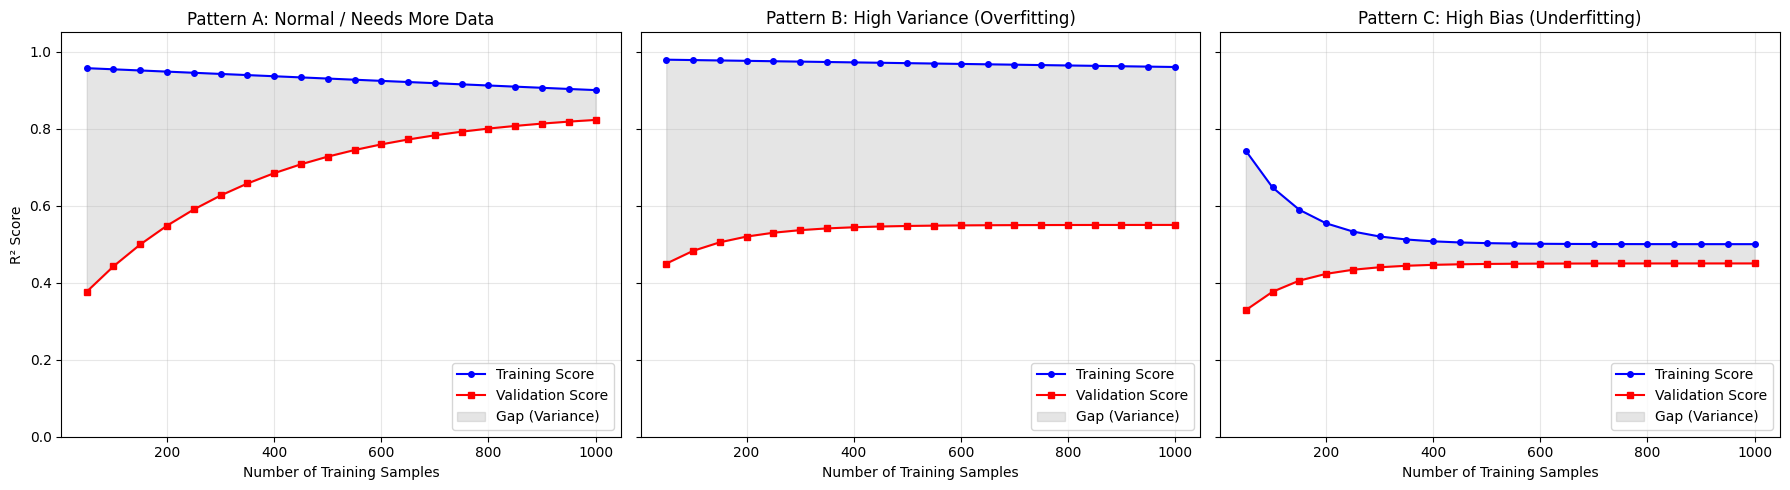

In [3]:
sizes = np.linspace(50, 1000, 20)
scenarios = ['normal', 'overfit', 'underfit']
titles = ['Pattern A: Normal / Needs More Data', 'Pattern B: High Variance (Overfitting)', 'Pattern C: High Bias (Underfitting)']

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, scenario in enumerate(scenarios):
    train, val = simulate_learning_curve(sizes, scenario)
    axes[i].plot(sizes, train, 'b-o', label='Training Score', markersize=4)
    axes[i].plot(sizes, val, 'r-s', label='Validation Score', markersize=4)
    axes[i].fill_between(sizes, val, train, color='gray', alpha=0.2, label='Gap (Variance)')
    
    axes[i].set_title(titles[i])
    axes[i].set_xlabel('Number of Training Samples')
    axes[i].grid(True, alpha=0.3)
    if i == 0: axes[i].set_ylabel('R² Score')
    axes[i].legend(loc='lower right')
    axes[i].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

### How to Diagnose Your Model

1. **Pattern A (Normal):** The validation score is still rising and the gap is narrowing. **Gathering more data will likely help.**

2. **Pattern B (Overfit):** There is a persistent, large gap between the curves. The training score remains high, but the validation score plateaus early. Adding data might help slightly, but you likely need **more regularization** or **fewer features**.

3. **Pattern C (Underfit):** Both scores converge very quickly at a low value. The gap is small, but the performance is poor. **Adding more data is useless here.** You need a **more complex model** or **better features**.

---

## Summary: When to Use Which

| Curve | X-axis | Primary Question | Actionable Result |
|-------|--------|------------------|-------------------|
| **Alpha Tuning** | Alpha (Penalty) | What is the best model settings? | Find the optimal hyperparameter peak |
| **Learning Curve** | Sample Size | Would more data help my model? | Decide if you need more data or a better model |

### How they work together

In practice, you often use both:
1. First, use an **Alpha Tuning Curve** (or GridSearchCV) to find the best settings for your model architecture.
2. Then, check the **Learning Curve** to see if your model has reached its potential with the current amount of data.